# Ground Truth Task1 (easy_positive) 시각화 & 리뷰
1. 아래 셀을 순서대로 실행하면 모든 쌍이 시각화됩니다.
2. 유사하지 않은 쌍의 **번호(idx)**를 `drop_indices`에 추가하세요.
3. 마지막 셀을 실행하면 drop된 쌍을 제외한 CSV가 저장됩니다.

In [9]:
import csv
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

BASE_DIR = r"C:\Users\playdata2\Desktop\SKN_AI_20\SKN20-FINAL-2TEAM(vb1)\design"
IMAGE_DIR = r"C:\Users\playdata2\Desktop\SKN_AI_20\SKN20-FINAL-2TEAM(vb1)\design\data\images(21,895개)"
CSV_PATH = os.path.join(BASE_DIR, "ground_truth", "ground_truth_task1.csv")

# CSV 로드
with open(CSV_PATH, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

print(f"총 {len(rows)}쌍 로드 완료")

총 15쌍 로드 완료


## easy_positive (같은 출원번호 다른 도면) 시각화

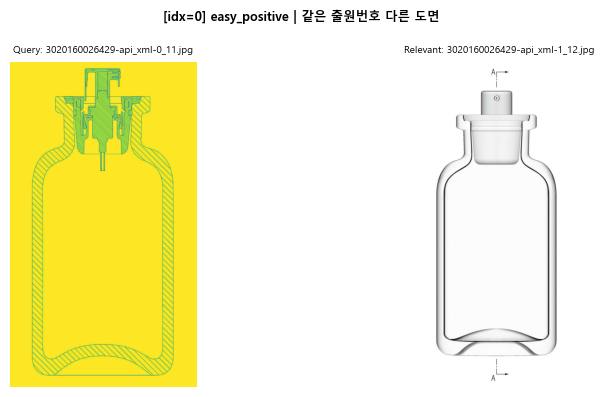

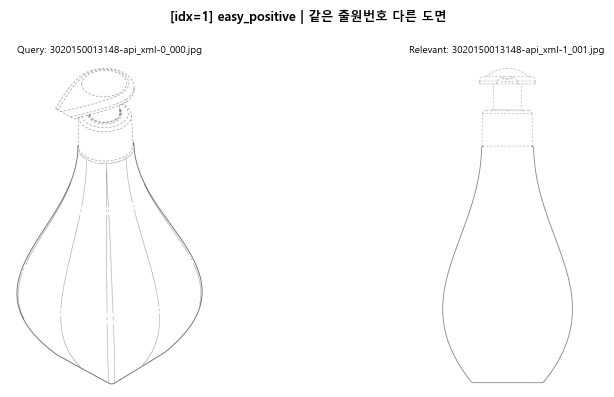

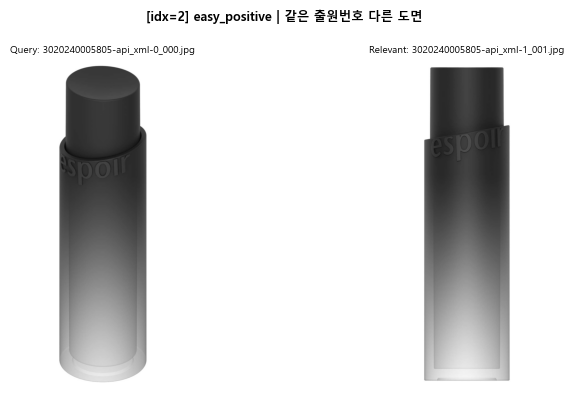

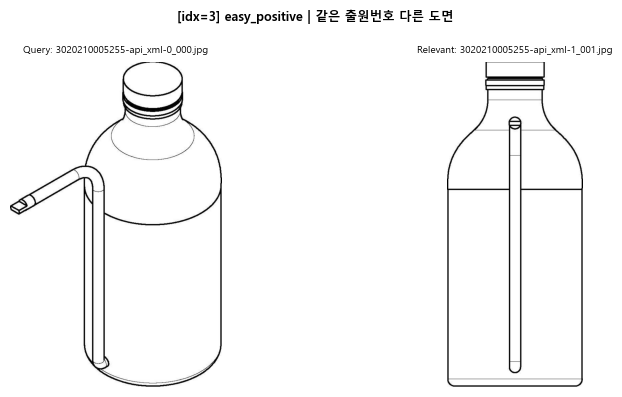

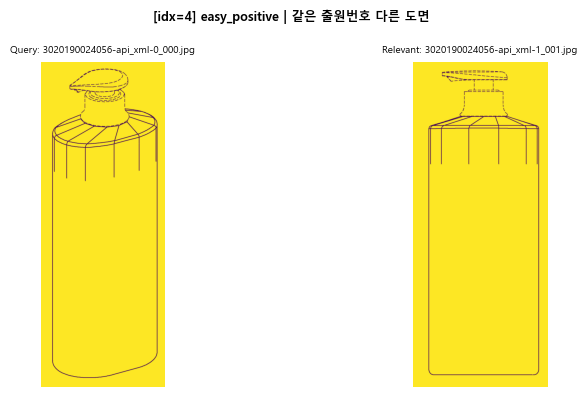

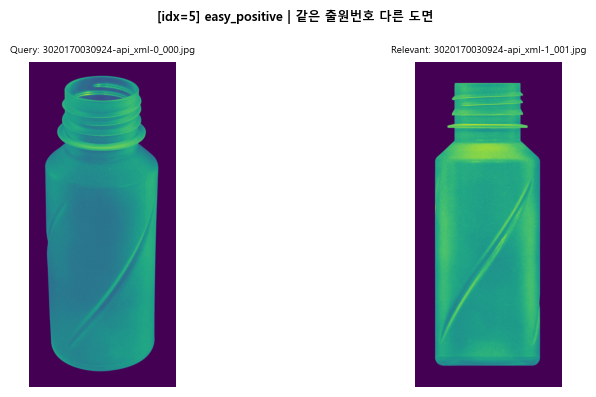

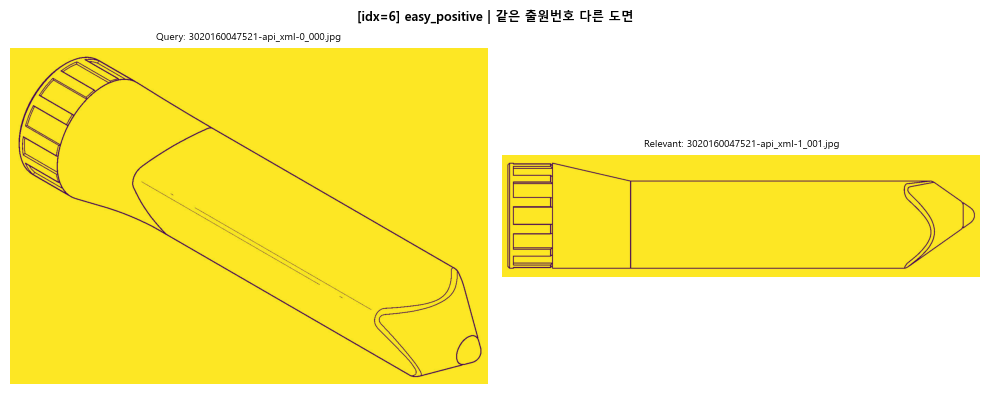

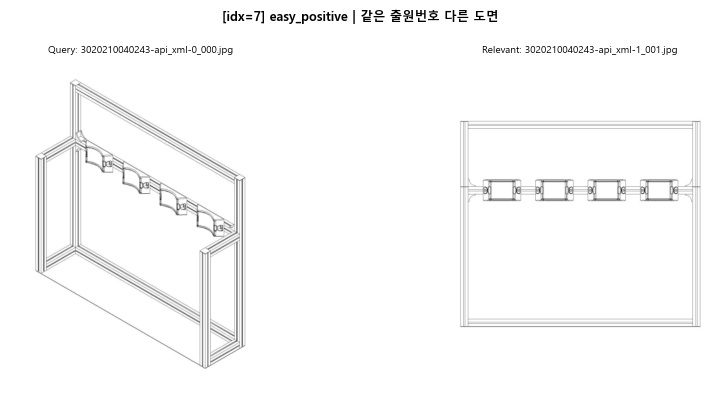

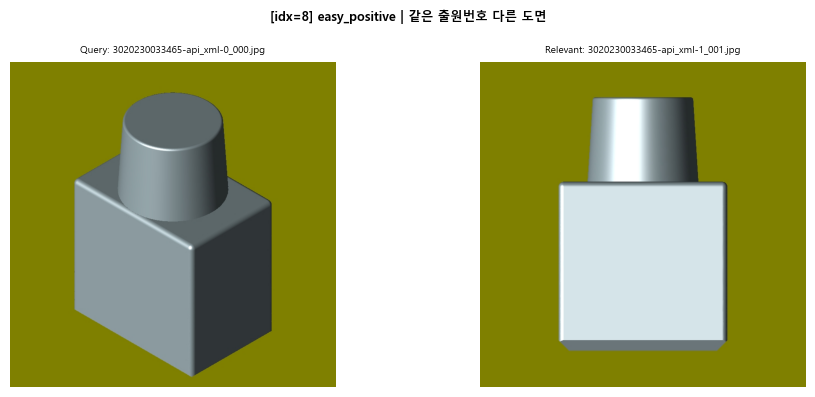

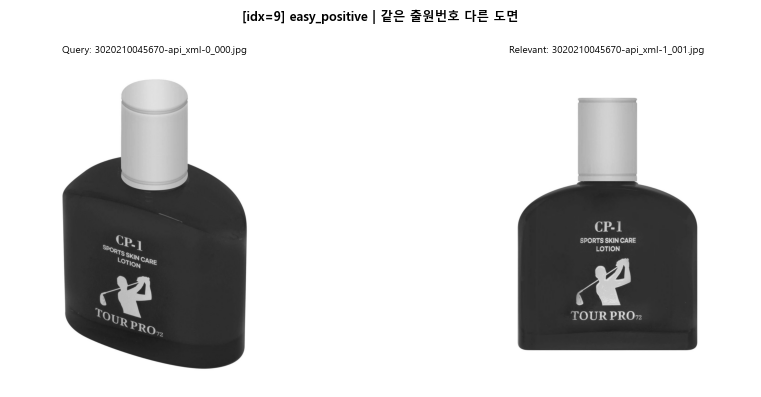

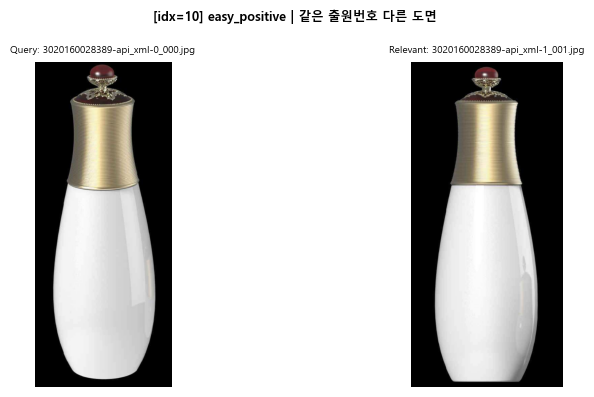

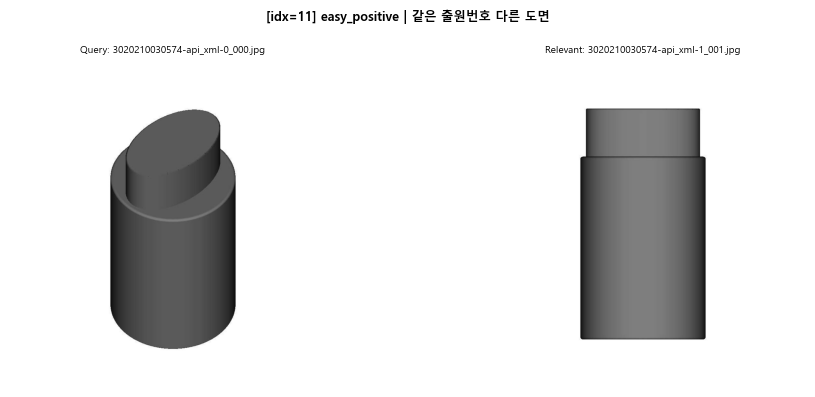

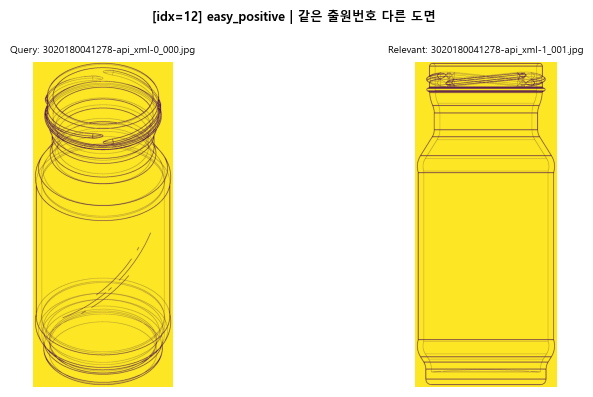

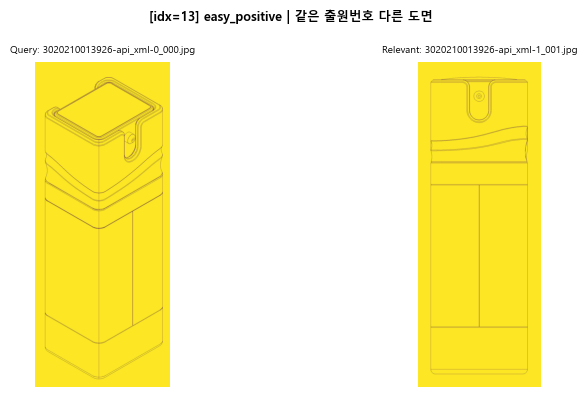

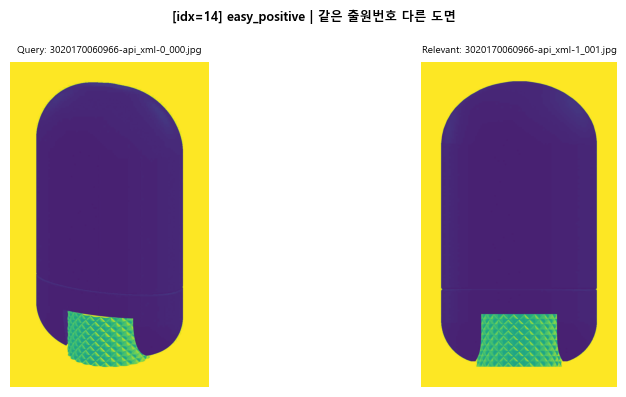

In [10]:
for idx, row in enumerate(rows):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    q_path = os.path.join(IMAGE_DIR, row['query_image'])
    r_path = os.path.join(IMAGE_DIR, row['relevant_image'])
    
    try:
        q_img = Image.open(q_path)
        r_img = Image.open(r_path)
    except Exception as e:
        print(f"[{idx}] 이미지 열기 실패: {e}")
        plt.close()
        continue
    
    axes[0].imshow(q_img)
    axes[0].set_title(f"Query: {row['query_image']}", fontsize=7)
    axes[0].axis('off')
    
    axes[1].imshow(r_img)
    axes[1].set_title(f"Relevant: {row['relevant_image']}", fontsize=7)
    axes[1].axis('off')
    
    fig.suptitle(f"[idx={idx}] {row['similarity_type']} | {row['note']}", fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Drop할 쌍 선택
위에서 유사하지 않다고 판단한 쌍의 **idx 번호**를 아래 리스트에 추가하세요.

In [11]:
# ============================================
# 여기에 drop할 idx 번호를 추가하세요!
# 예: drop_indices = [3, 15, 22]
# ============================================
drop_indices = [1,3,5,8,10,11,12,13]


print(f"Drop 대상: {len(drop_indices)}쌍")
print(f"남는 쌍: {len(rows) - len(drop_indices)}쌍")

Drop 대상: 8쌍
남는 쌍: 7쌍


In [ ]:
# Drop 적용 후 새 CSV 저장
filtered_rows = [r for i, r in enumerate(rows) if i not in set(drop_indices)]

OUTPUT_CSV = os.path.join(BASE_DIR, "ground_truth", "ground_truth_task1_filtered.csv")
with open(OUTPUT_CSV, 'w', newline='', encoding='utf-8-sig') as f:
    writer = csv.DictWriter(f, fieldnames=['query_image', 'relevant_image', 'similarity_type', 'note'])
    writer.writeheader()
    writer.writerows(filtered_rows)

print(f"원본: {len(rows)}쌍 -> 필터링 후: {len(filtered_rows)}쌍")
print(f"Drop된 쌍: {len(drop_indices)}개")
print(f"저장 완료: {os.path.abspath(OUTPUT_CSV)}")

원본: 15쌍 -> 필터링 후: 7쌍
Drop된 쌍: 8개
저장 완료: C:\Users\playdata2\Desktop\SKN_AI_20\SKN20-FINAL-2TEAM(vb1)\design\ground_truth\ground_truth_task1_filtered_2.csv


## (선택) Drop한 쌍 확인
어떤 쌍을 drop했는지 다시 확인하고 싶을 때 실행하세요.

In [ ]:
if drop_indices:
    for idx in sorted(drop_indices):
        row = rows[idx]
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        try:
            q_img = Image.open(os.path.join(IMAGE_DIR, row['query_image']))
            r_img = Image.open(os.path.join(IMAGE_DIR, row['relevant_image']))
        except Exception:
            plt.close()
            continue
        
        axes[0].imshow(q_img)
        axes[0].set_title(f"Query: {row['query_image']}", fontsize=7)
        axes[0].axis('off')
        
        axes[1].imshow(r_img)
        axes[1].set_title(f"Relevant: {row['relevant_image']}", fontsize=7)
        axes[1].axis('off')
        
        fig.suptitle(f"[DROPPED idx={idx}] {row['note']}", fontsize=9, color='red', fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print("Drop된 쌍이 없습니다.")